In [ ]:
from google.colab import files
uploaded = files.upload()


Saving dataset.csv to dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)


In [ ]:
df = pd.read_csv('dataset.csv')
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [ ]:
df.isnull().sum()


,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [ ]:
df.describe()


,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [ ]:
print(f"Number of unique genres: {df['track_genre'].nunique()}")
df['track_genre'].value_counts()


Number of unique genres: 114


,count
track_genre,
acoustic,1000
afrobeat,1000
alt-rock,1000
alternative,1000
ambient,1000
...,...
techno,1000
trance,1000
trip-hop,1000


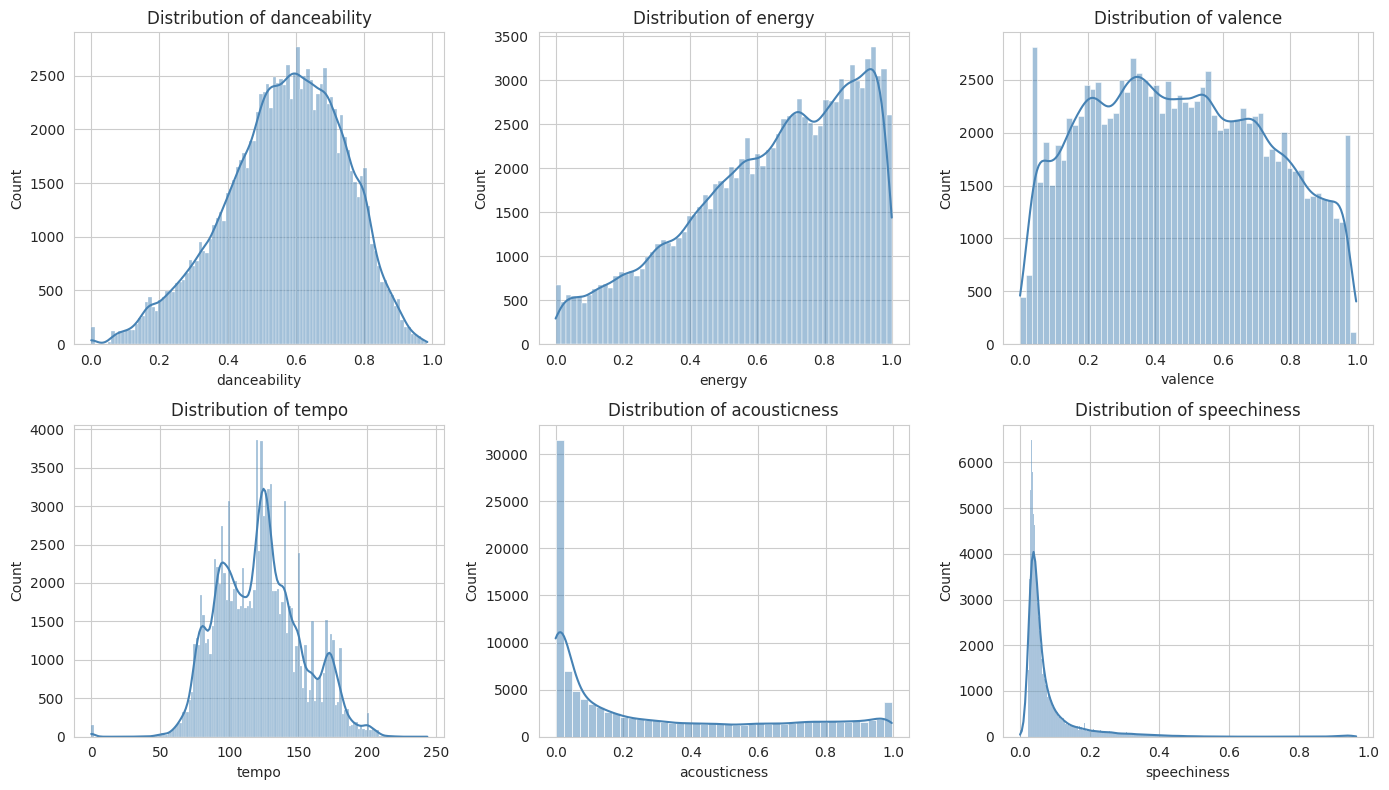

In [ ]:
features = ['danceability', 'energy', 'valence', 'tempo', 'acousticness', 'speechiness']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(df[feature], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()


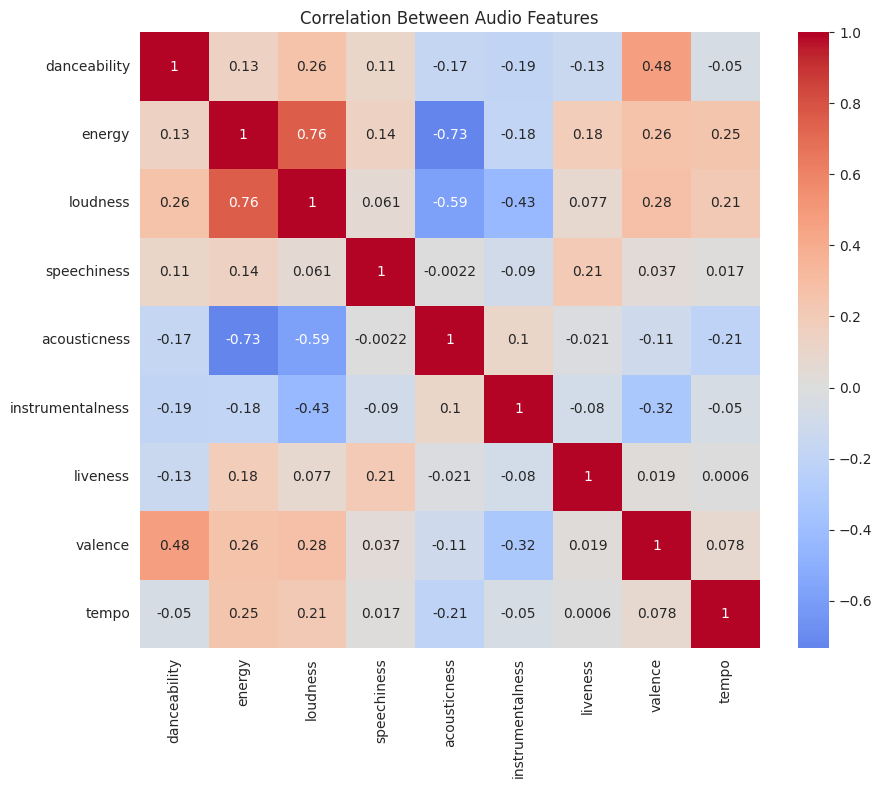

In [ ]:
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

plt.figure(figsize=(10, 8))
sns.heatmap(df[audio_features].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Audio Features')
plt.show()


In [ ]:
mood_mapping = {
    # Happy / Energetic
    'pop': 'Happy', 'dance': 'Happy', 'disco': 'Happy', 'party': 'Happy',
    'happy': 'Happy', 'funk': 'Happy', 'latin': 'Happy', 'reggaeton': 'Happy',
    'edm': 'Happy', 'house': 'Happy', 'electronic': 'Happy',

    # Calm / Relaxed
    'classical': 'Calm', 'sleep': 'Calm', 'ambient': 'Calm', 'piano': 'Calm',
    'acoustic': 'Calm', 'chill': 'Calm', 'jazz': 'Calm', 'folk': 'Calm',
    'new-age': 'Calm', 'study': 'Calm',

    # Intense / Aggressive
    'metal': 'Intense', 'rock': 'Intense', 'hard-rock': 'Intense',
    'heavy-metal': 'Intense', 'punk': 'Intense', 'punk-rock': 'Intense',
    'hardcore': 'Intense', 'grunge': 'Intense', 'industrial': 'Intense',

    # Melancholic / Emotional
    'sad': 'Melancholic', 'blues': 'Melancholic', 'soul': 'Melancholic',
    'r-n-b': 'Melancholic', 'indie': 'Melancholic', 'singer-songwriter': 'Melancholic',
    'emo': 'Melancholic', 'romance': 'Melancholic'
}

# Apply mapping (genres not in dict become 'Other')
df['mood'] = df['track_genre'].map(mood_mapping).fillna('Other')
df['mood'].value_counts()


,count
mood,
Other,76000
Happy,11000
Calm,10000
Intense,9000
Melancholic,8000


In [ ]:
df_mood = df[df['mood'] != 'Other'].copy()
print(f"Filtered dataset shape: {df_mood.shape}")
df_mood['mood'].value_counts()


Filtered dataset shape: (38000, 22)


,count
mood,
Happy,11000
Calm,10000
Intense,9000
Melancholic,8000


/tmp/ipykernel_15223/113931695.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mood, x='mood', y='energy', ax=axes[0,0], palette='Set2')
/tmp/ipykernel_15223/113931695.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mood, x='mood', y='valence', ax=axes[0,1], palette='Set2')
/tmp/ipykernel_15223/113931695.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mood, x='mood', y='danceability', ax=axes[1,0], palette='Set2')
/tmp/ipykernel_15223/113931695.py:12: FutureWarning: 

Passing `palette` without assigning `h

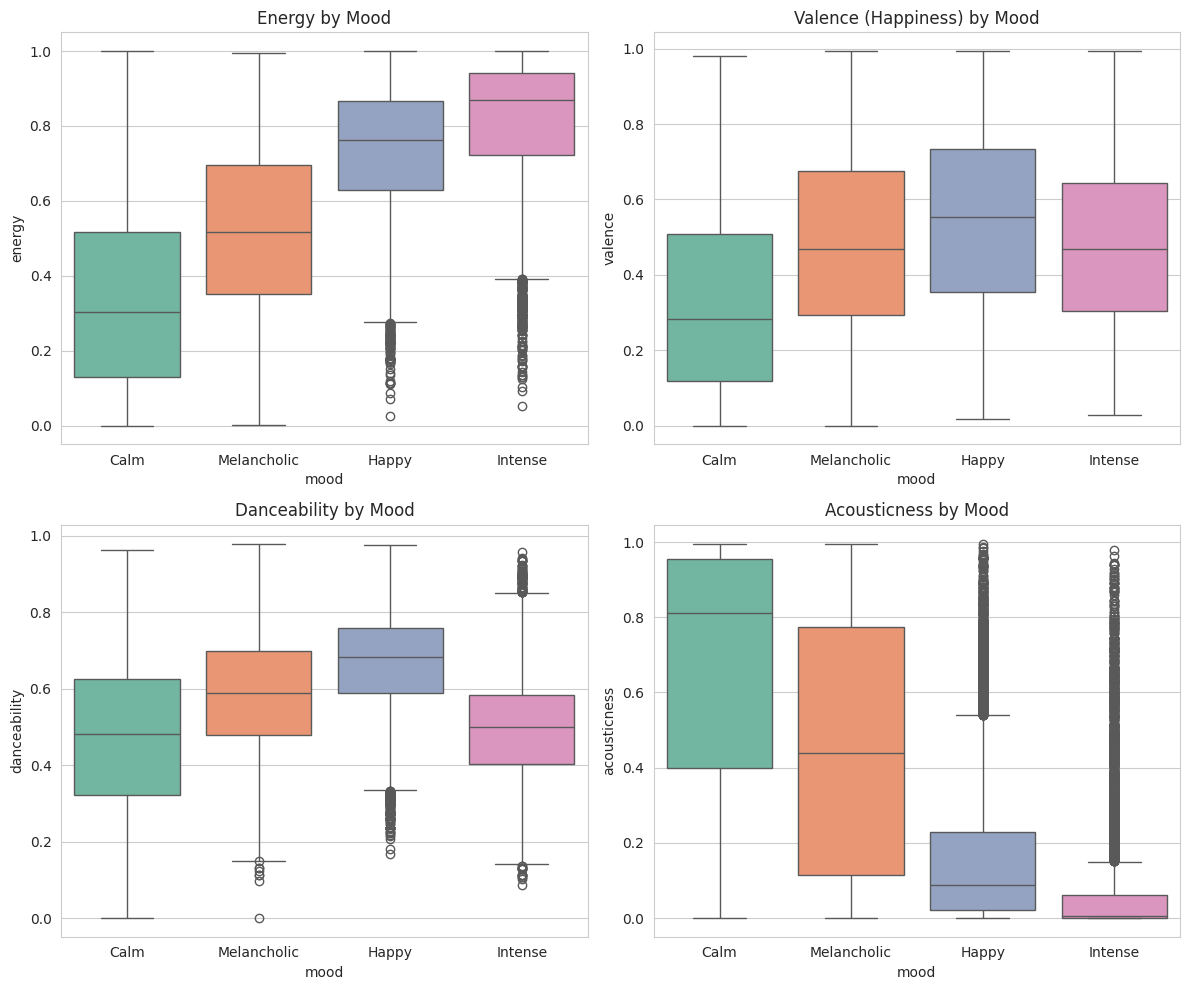

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.boxplot(data=df_mood, x='mood', y='energy', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Energy by Mood')

sns.boxplot(data=df_mood, x='mood', y='valence', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Valence (Happiness) by Mood')

sns.boxplot(data=df_mood, x='mood', y='danceability', ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Danceability by Mood')

sns.boxplot(data=df_mood, x='mood', y='acousticness', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Acousticness by Mood')

plt.tight_layout()
plt.show()


In [ ]:
df_mood.to_csv('spotify_with_moods.csv', index=False)
files.download('spotify_with_moods.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>